In [1]:
from src.constants import PROCESSED_DATA_PATH, RAW_DATA_PATH

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.colors as mcolors
import umap
import umap.plot

from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.signal.windows import gaussian


unit_id = "116b"

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)


### Setup

Loading

In [2]:
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_total.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")

sessions        = loadmat(PROCESSED_DATA_PATH / unit_id / "session_epochs.mat")["session_epochs"].squeeze()
sessions        = nap.IntervalSet(start=sessions[:, 0], end=sessions[:, 1], time_units='s')
epochs_pre_ttx  = sleep_states[sleep_states['state'] == 'wake'].intersect(hd_angle.time_support)

Preprocessing

<Axes: ylabel='Count'>

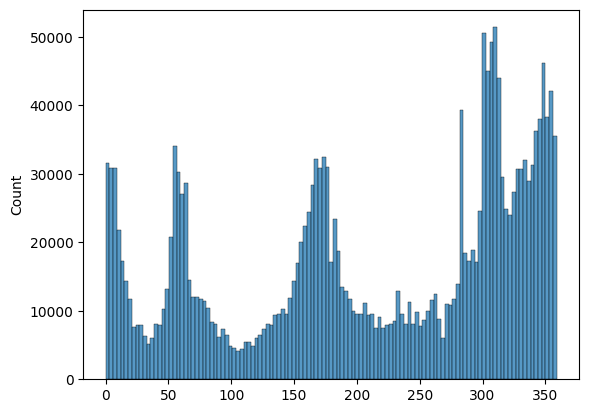

In [6]:
sns.histplot(hd_angle.values)

In [3]:
wake_bin = 0.1

kernel = gaussian(M=200, std=3)
epochs = epochs_pre_ttx
hd_angle = hd_angle.bin_average(bin_size=wake_bin, ep=epochs)
wake_binned = hd_spikes.count(bin_size=wake_bin, ep=epochs)
wake_rate = np.sqrt(wake_binned.convolve(kernel))

print(np.prod(wake_rate.shape))
wake_rate.shape

1708695


(21095, 81)

UMAP

<Axes: >

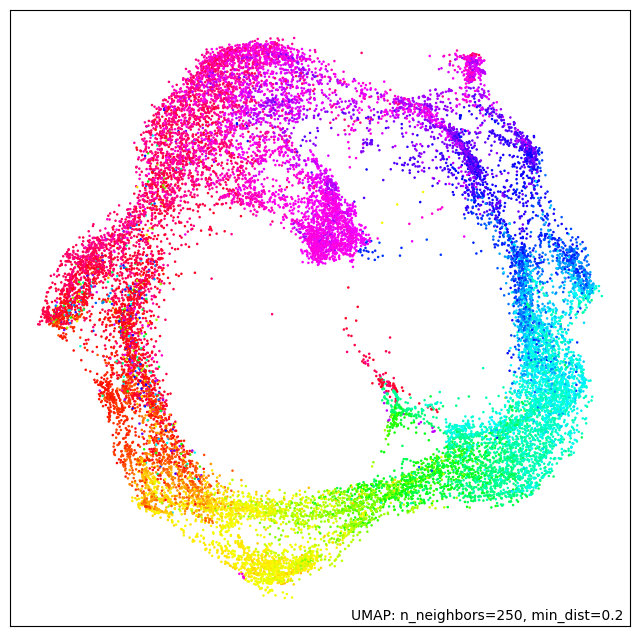

In [5]:
reducer = umap.UMAP(n_neighbors=250,
                    min_dist=0.2,
                    n_components=2,
                    metric='euclidean'
                    )

wake_embds = reducer.fit_transform(wake_rate)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

In [6]:
manifold = nap.TsdFrame(t=wake_rate.t, d=wake_embds, columns=['x', 'y'])
manifold

Time (s)           x        y
----------  --------  -------
16663.15    -7.03739  22.2576
16663.25    -6.99917  22.2279
16663.35    -6.96727  22.2051
16663.45    -6.94461  22.1886
16663.55    -6.92251  22.1478
16663.65    -6.89453  22.0917
16663.75    -6.82695  22.0049
...
18771.95    -3.07707  25.6664
18772.05    -2.9941   25.6031
18772.15    -2.92264  25.5424
18772.25    -2.95772  25.4961
18772.35    -2.9432   25.5815
18772.45    -2.23609  25.5558
18772.55    -1.38792  25.662
dtype: float32, shape: (21095, 2)

In [44]:
manifold.save(PROCESSED_DATA_PATH / unit_id / "manifold_wake_pre_ttx")

In [7]:
hd_spikes = hd_spikes.restrict(epochs)

In [47]:
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes_wake_pre_ttx")

In [8]:
pulses = loadmat(PROCESSED_DATA_PATH / unit_id / "pulses.mat")['pulses']
pulses = pulses.mean(axis=1)

In [49]:
np.save(PROCESSED_DATA_PATH / unit_id / "pulses", pulses)

### Viz

In [16]:
manifold_cosine = nap.load_file(PROCESSED_DATA_PATH / unit_id / "manifold_wake_pre_ttx.npz")

In [9]:
center = manifold.mean(axis=0)

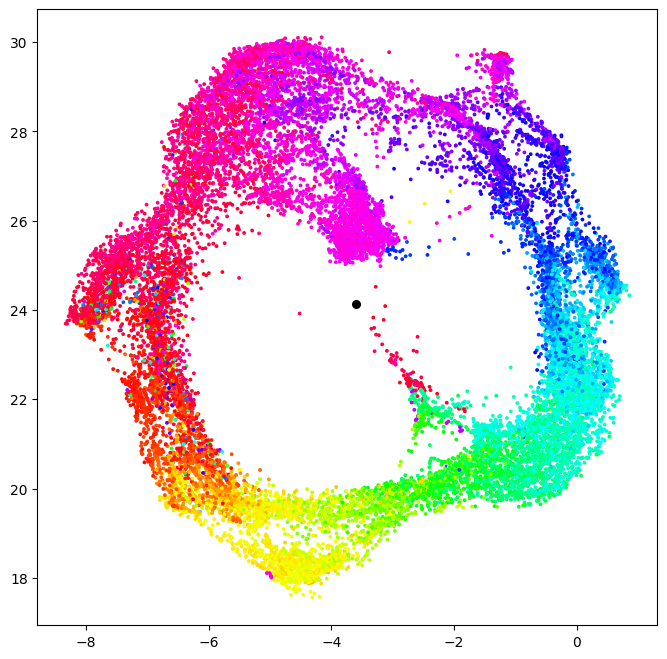

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(manifold['x'], manifold['y'], c=hd_angle, cmap='hsv', s=3)
ax.scatter(center[0], center[1], c='black', s=30)

<Axes: ylabel='Count'>

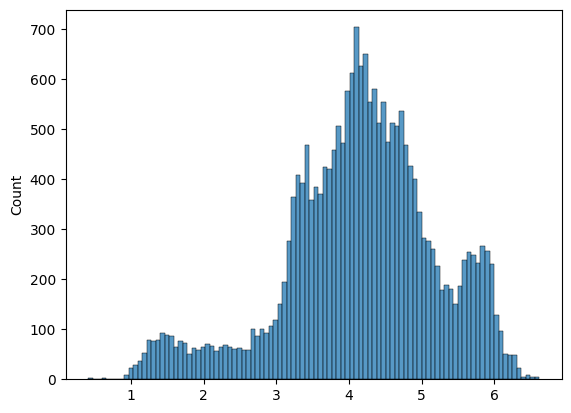

In [11]:
radii = np.sqrt((manifold['x'] - center[0]).to_numpy()**2 + (manifold['y'] - center[1]).to_numpy()**2)
sns.histplot(radii, bins=100)

In [12]:
indices = np.where((radii < 2) | (radii > 6) )[0]

# Find indices where the jump is greater than 1
jumps = np.where(np.diff(indices) > 1)[0] + 1
periods = np.split(indices, jumps)

start = [manifold.t[p[0]].item() for p in periods]
end = [manifold.t[p[-1]].item() for p in periods]

outliers = nap.IntervalSet(start=start, end=end, time_units='s')
outliers

C:\Users\iii9781\AppData\Local\Temp\ipykernel_29688\1795749191.py:10: UserWarning: Some epochs have no duration
  outliers = nap.IntervalSet(start=start, end=end, time_units='s')


index    start     end
0        16746.95  16747.25
1        16901.05  16901.35
2        16907.75  16907.85
3        16928.55  16928.75
4        16936.35  16936.75
5        17004.85  17005.35
6        17008.25  17008.35
...      ...       ...
72       18727.35  18734.15
73       18735.65  18739.45
74       18739.95  18744.75
75       18745.75  18748.25
76       18748.65  18754.55
77       18763.45  18766.75
78       18769.05  18772.45
shape: (79, 2), time unit: sec.

In [51]:
outliers.save(PROCESSED_DATA_PATH / unit_id / "manifold_outliers_wake_pre_ttx")

In [19]:
import pynaviz as viz
from pynaviz import scope

vid = viz.VideoHandler(RAW_DATA_PATH / unit_id / "Basler_acA1300-200um__23157472__20230607_205412188.avi",
                        time=pulses)

In [20]:
scope({'units': hd_spikes, 'manifold_euclidean': manifold, 'manifold_cosine': manifold_cosine, 'video': vid, 'outliers': outliers})

AudioHandler failed to close the audiovideo stream.
Unable to stop background thread with exception: 'PlotVideo' object has no attribute '_stop_threads'


Error in scheduler-task task:
Traceback (most recent call last):
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\_loop.py", line 172, in wrapper
    await async_func(*args)
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\_scheduler.py", line 179, in __scheduler_task
    canvas._process_events()
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\base.py", line 382, in _process_events
    self.__maybe_emit_resize_event()
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\base.py", line 353, in __maybe_emit_resize_event
    self._canvas_context._rc_set_size_dict(self._size_info)
  File "c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\rendercanvas\contexts\basecontext.py", line 54, in _rc_set_size_dict
    self._wgpu_context.set_physical_size(*size_info["physical_size"])
  File "c:\Users\